# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

**Data validation**
- I used the recipe_site_traffic_2212.csv file and validated each column:

    - Numerical features – calories, carbohydrate, sugar, protein

        - Checked for missing values and outliers.
        - All four were strongly right‑skewed, so I removed extreme outliers using the IQR rule and then imputed
          remainding missing values with the median.
      
    - Categorical features - category, servings, high_traffic

        - category: Fixed inconsistent labels (e.g. “Chicken Breast” → “Chicken”); Converted to a categorical variable
          for modelling.
        - servings: Cleaned text values (e.g. “4 as a snack” → “4”); Converted to an ordered categorical variable with
          levels 1, 2, 4, 6; Created an ordinal numeric version servings_ordinal for use in models.
        - high_traffic (target): Filled missing values with 0, replaced “High” with 1; Converted to a binary
          categorical variable (0 = Not high traffic, 1 = high traffic).


No duplicate rows were found.

**Exploratory analysis**
- Single‑variable graphics:

    - Histograms of calories, carbohydrate, sugar, protein
        - These show very skewed distributions: most recipes have relatively low values with a long tail of
          high‑value recipes. 

    - Bar chart of high_traffic
        - A simple countplot shows slightly more high‑traffic recipes than low‑traffic ones (60.1% high-traffic).

- Multi‑variable graphic
    - Correlation heatmap of the four nutritional variables
    - Correlations are all weak (around −0.07 to 0.18), meaning each feature is relatively independent of eachover
  
- Hypothesis testing and findings:

    - To get a better undestanding on which features are most likely to affect recipe high_traffic, hypothesis testing
      was used with significance level 0.05:

    - For continuous variables, I used Mann–Whitney U tests:
        - Calories and protein show statistically significant differences between high and low traffic recipes.
    - For categorical variables (category, servings) I used chi‑square tests:
        - Category is significantly associated with high traffic; servings is weaker.

From these tests I deduced calories, protein, and category as the most important predictors, since these values passed the tests.

![image](image.png)



**Model development**

- Problem type:

    - This is a Binary Classification problem, so we will need relevent models

- Features used
    - Numeric: calories, carbohydrate, sugar, protein, servings_ordinal
    - Categorical: one‑hot encoded category dummies.

- The data was split into train (80%) and test (20%) sets with stratification on high_traffic.

- Baseline model – Logistic regression
    - Standardised the numeric features using StandardScaler.
    - Fitted a logistic regression model (max_iter=200).
    - This model is simple and interpretable; coefficients show how each feature affects the odds of high traffic.
- Comparison model – Random forest
    - Fitted a RandomForestClassifier without scaling (not required).
    - Used RandomizedSearchCV with 5‑fold cross‑validation to tune hyperparameters (n_estimators, max_depth,
      min_samples_split, min_samples_leaf).
    - Selected the best model and refit it on the training data.


**Model Evaluation**

- Both models achieved an identical test accuracy of 80.42% on the holdout dataset, driven by the highly dominant traffic signals present in parent categories like Vegetables and Potatoes. However, when evaluating the underlying probability distributions via ROC AUC, the Baseline Logistic Regression model out-performed the Tuned Random Forest (0.8815 vs. 0.8770). The linear baseline established a cleaner, more mathematically stable separation threshold, proving that the relationship between core recipe categories and high traffic is highly linear and robust. Note: For logistic model, categorical features are on a different scale than the standardized numerical features, so their bar heights cannot be directly compared.



- Standardized Logistic Model Metrics

![image-2](image-2.png)

- Tuned Random Forest Classfier Metrics

![image-3](image-3.png)

**Business Metrics & Performance**

- To align with the business goal of maximizing high-traffic homepage exposure while strictly minimizing underperforming content, Precision was selected as our key performance indicator.
  - Pre-model Busines Performance: The current selection of recipes yields a homepage success rate of roughly 60.1%.
  - The Tuned Random Forest Deployment: Delivers a precision rate of 80.85%.
  - The Baseline Logistic Regression Deployment: Delivers the maximum precision rate of 82.22%.

- Therefore, we recommend deploying the Standardized Logistic Regression model. When this model flags a recipe as a high-traffic winner, it carries an 82.22% guarantee of being a True Positive (actual high traffic recipe), successfully protecting the homepage from user engagement drops.”


**Final Recommendations**

- Deploy the Standardized Logistic Regression Pipeline: Instead of using the heavier tree ensemble, deploy the logistic model pipeline. It is mathematically lightweight, executes faster, and has the highest precision on our target metric.
- Lean Heavily Into Core Linear Categories: Prioritize new recipe creation and homepage real estate for Vegetable and Potato dishes, as the linear baseline confirms these yield the highest immediate probability jumps for site traffic.

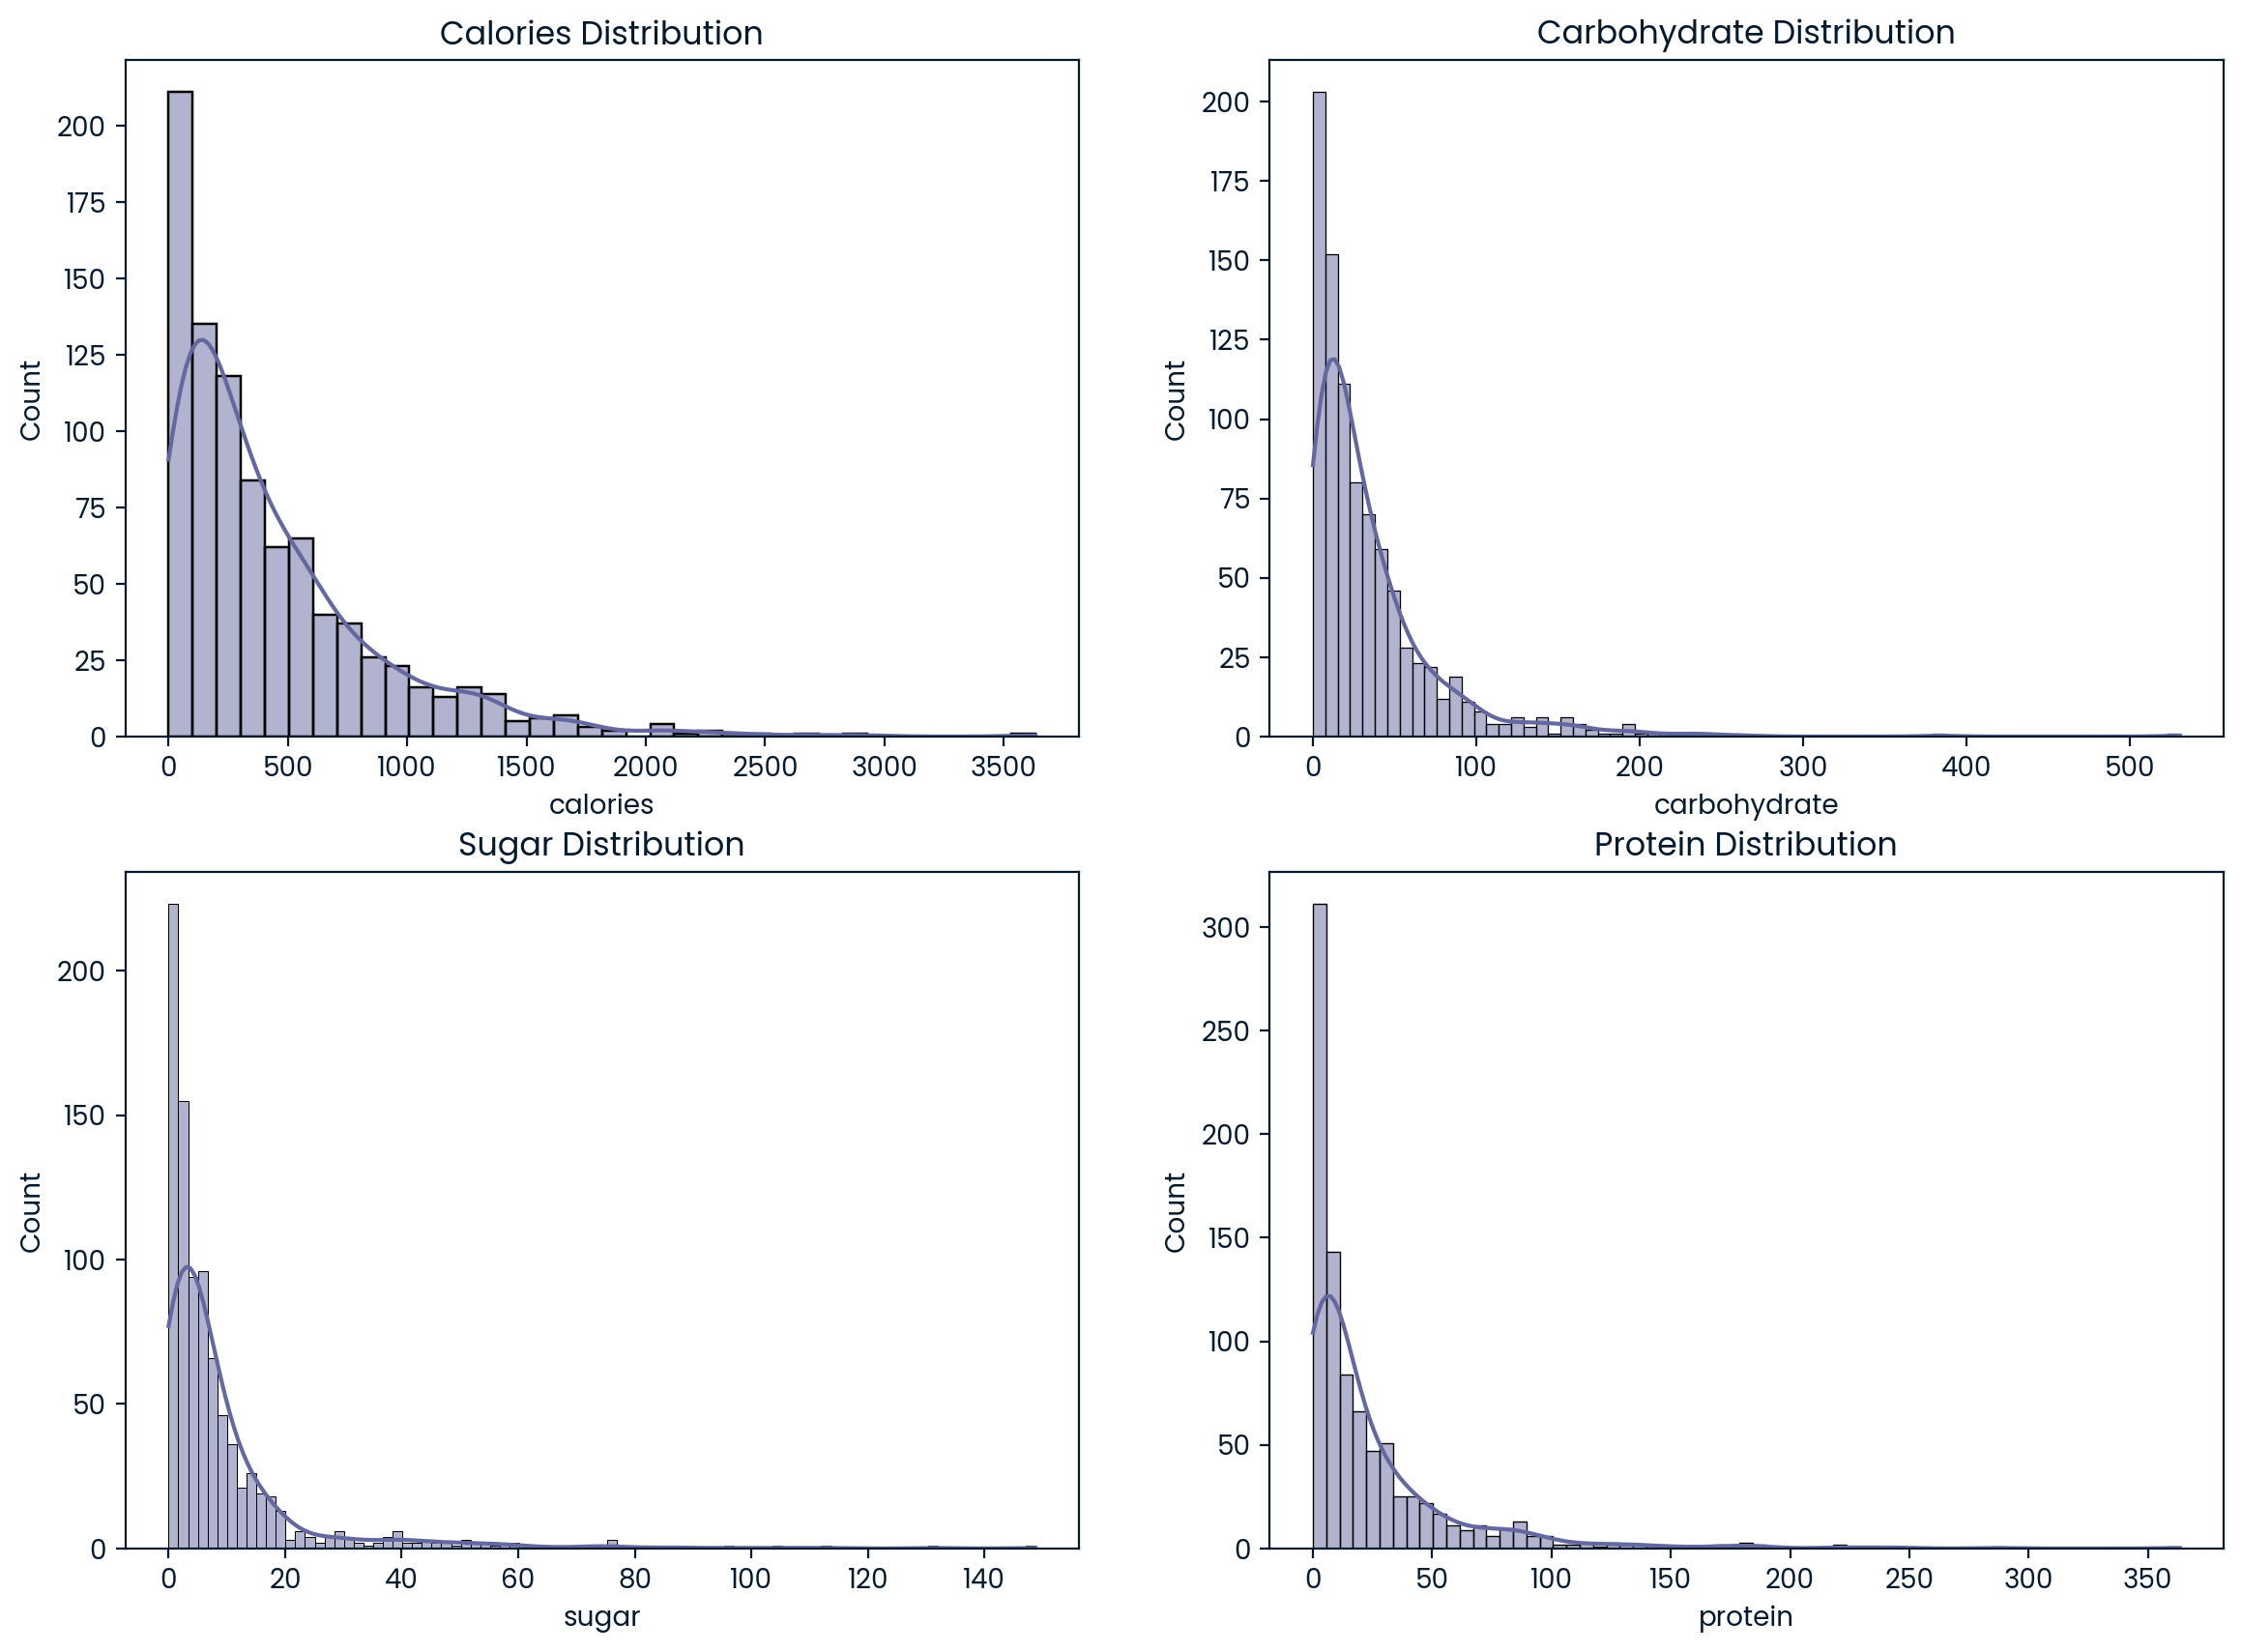

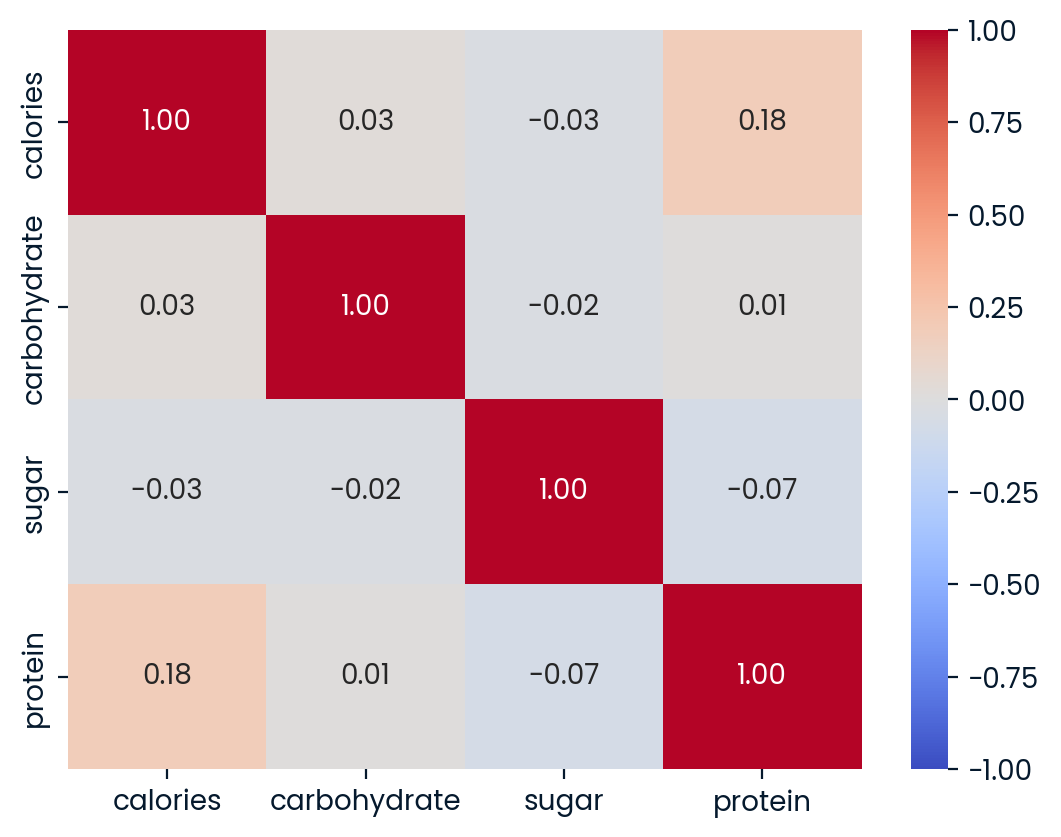

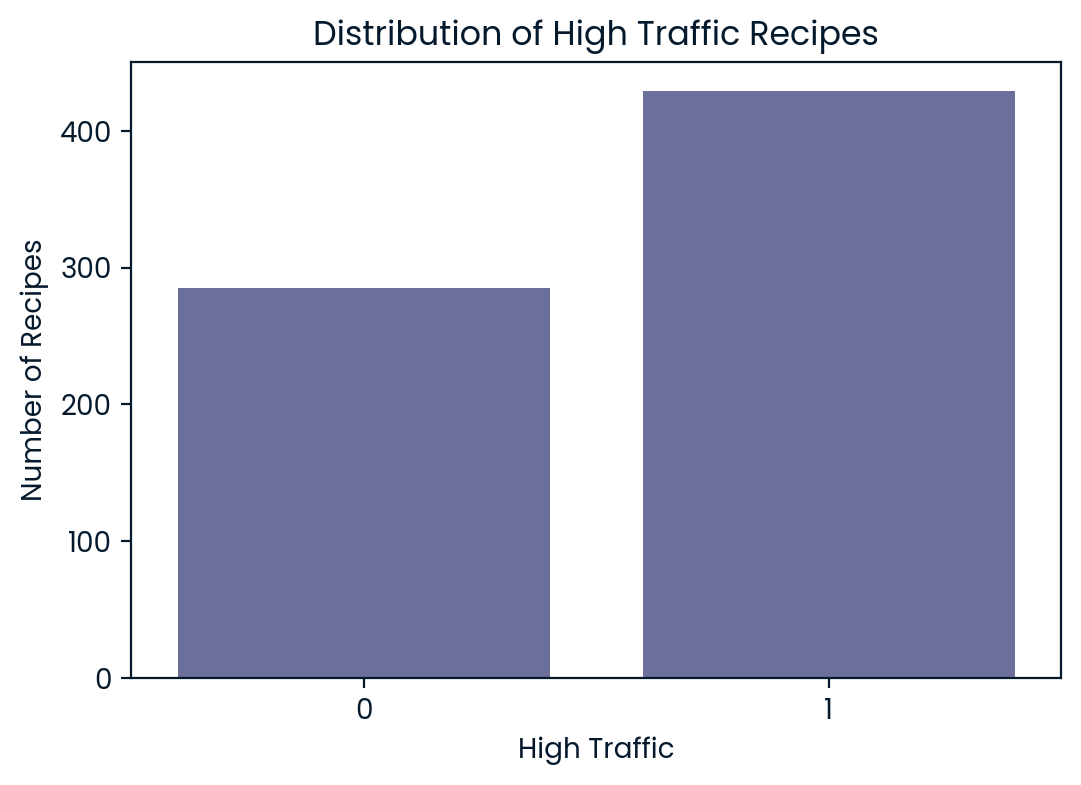

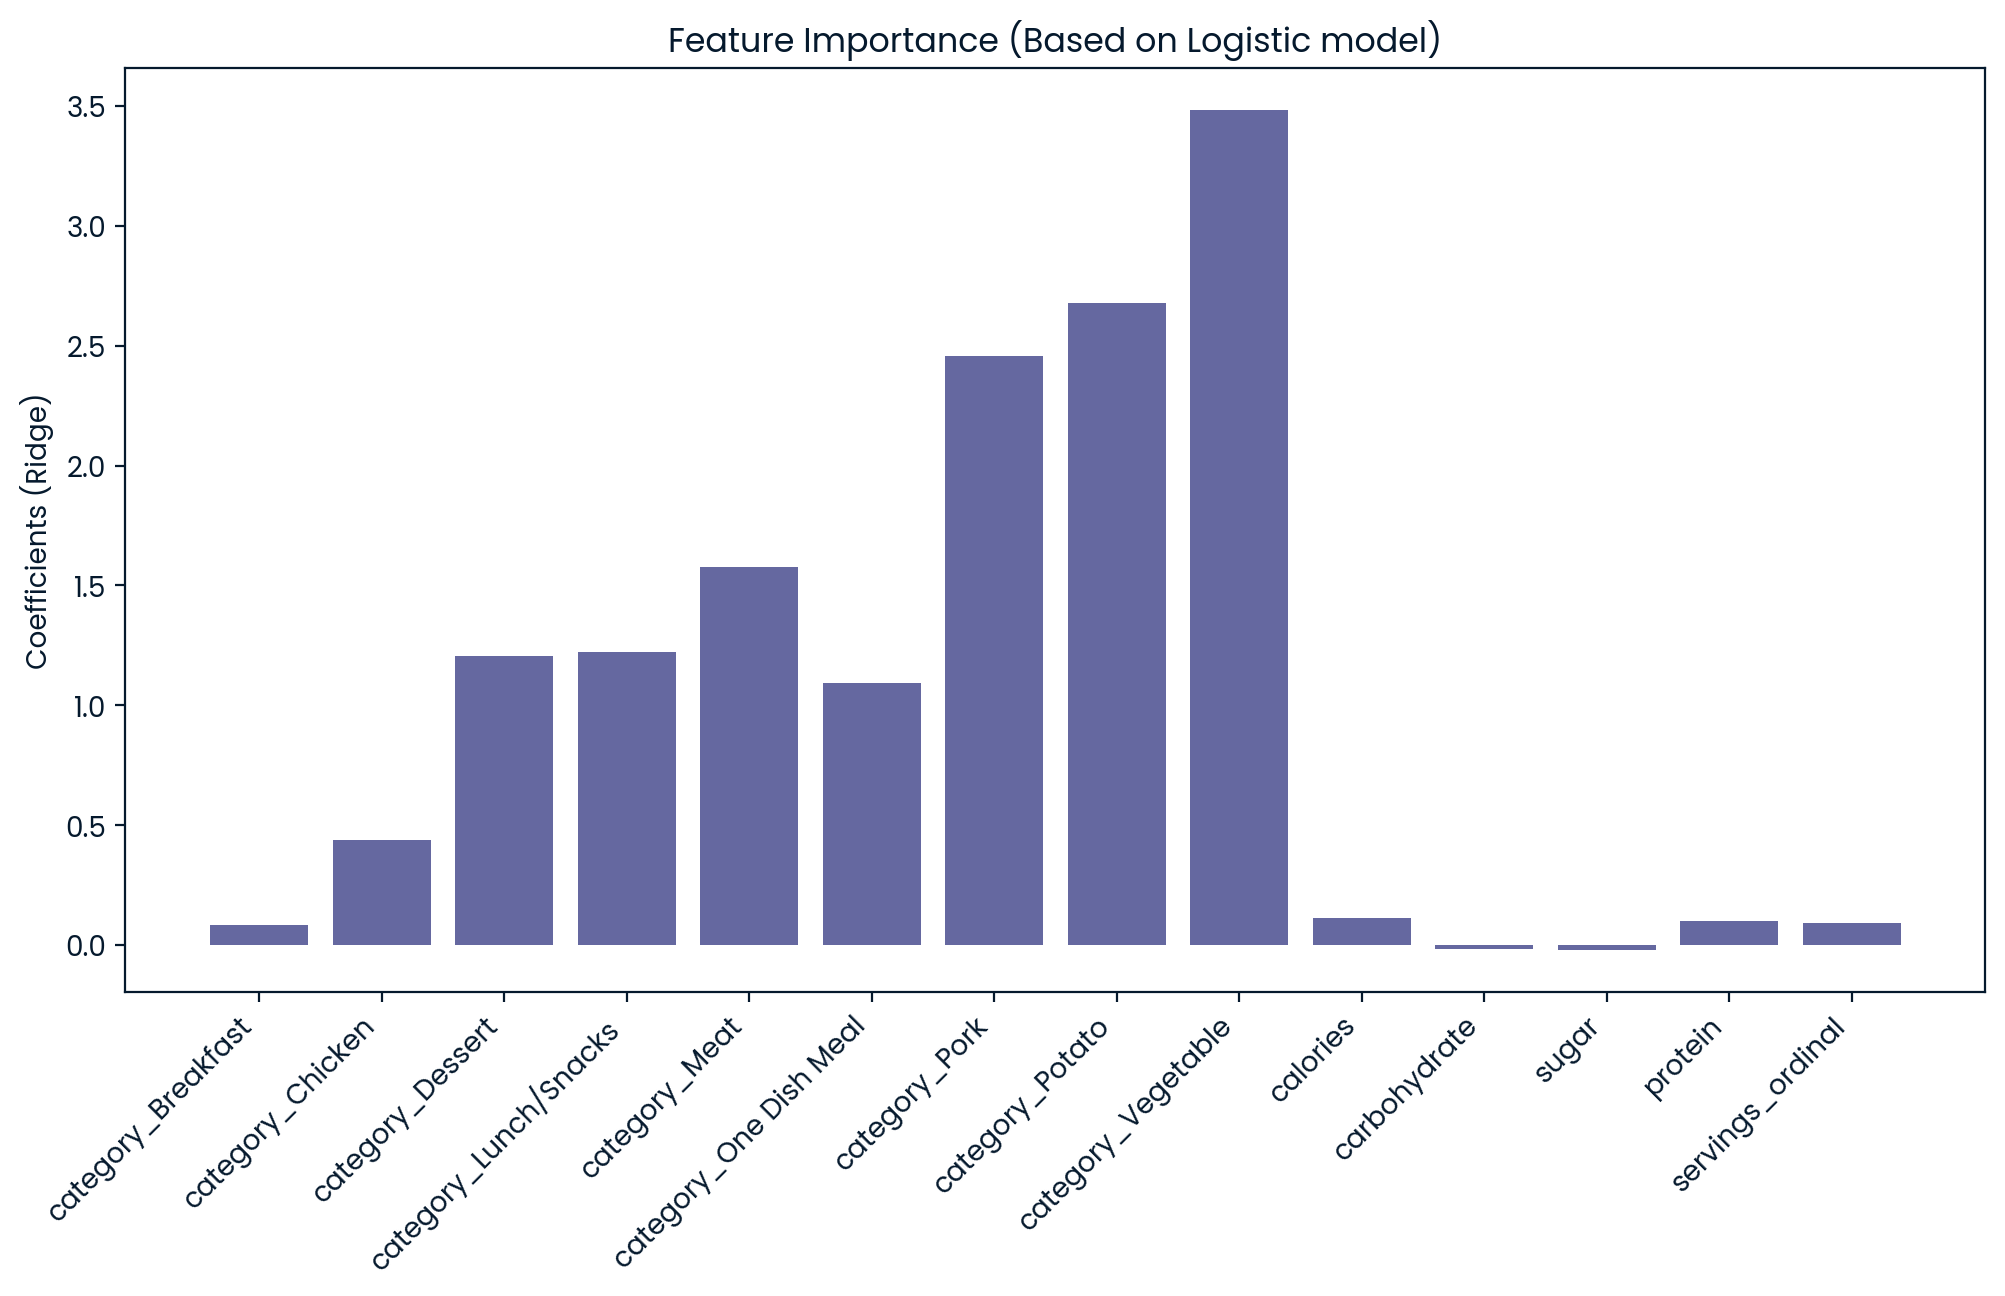

Accuracy: 0.8041958041958042
Precision: 0.8222222222222222
ROC AUC: 0.8814769481844146


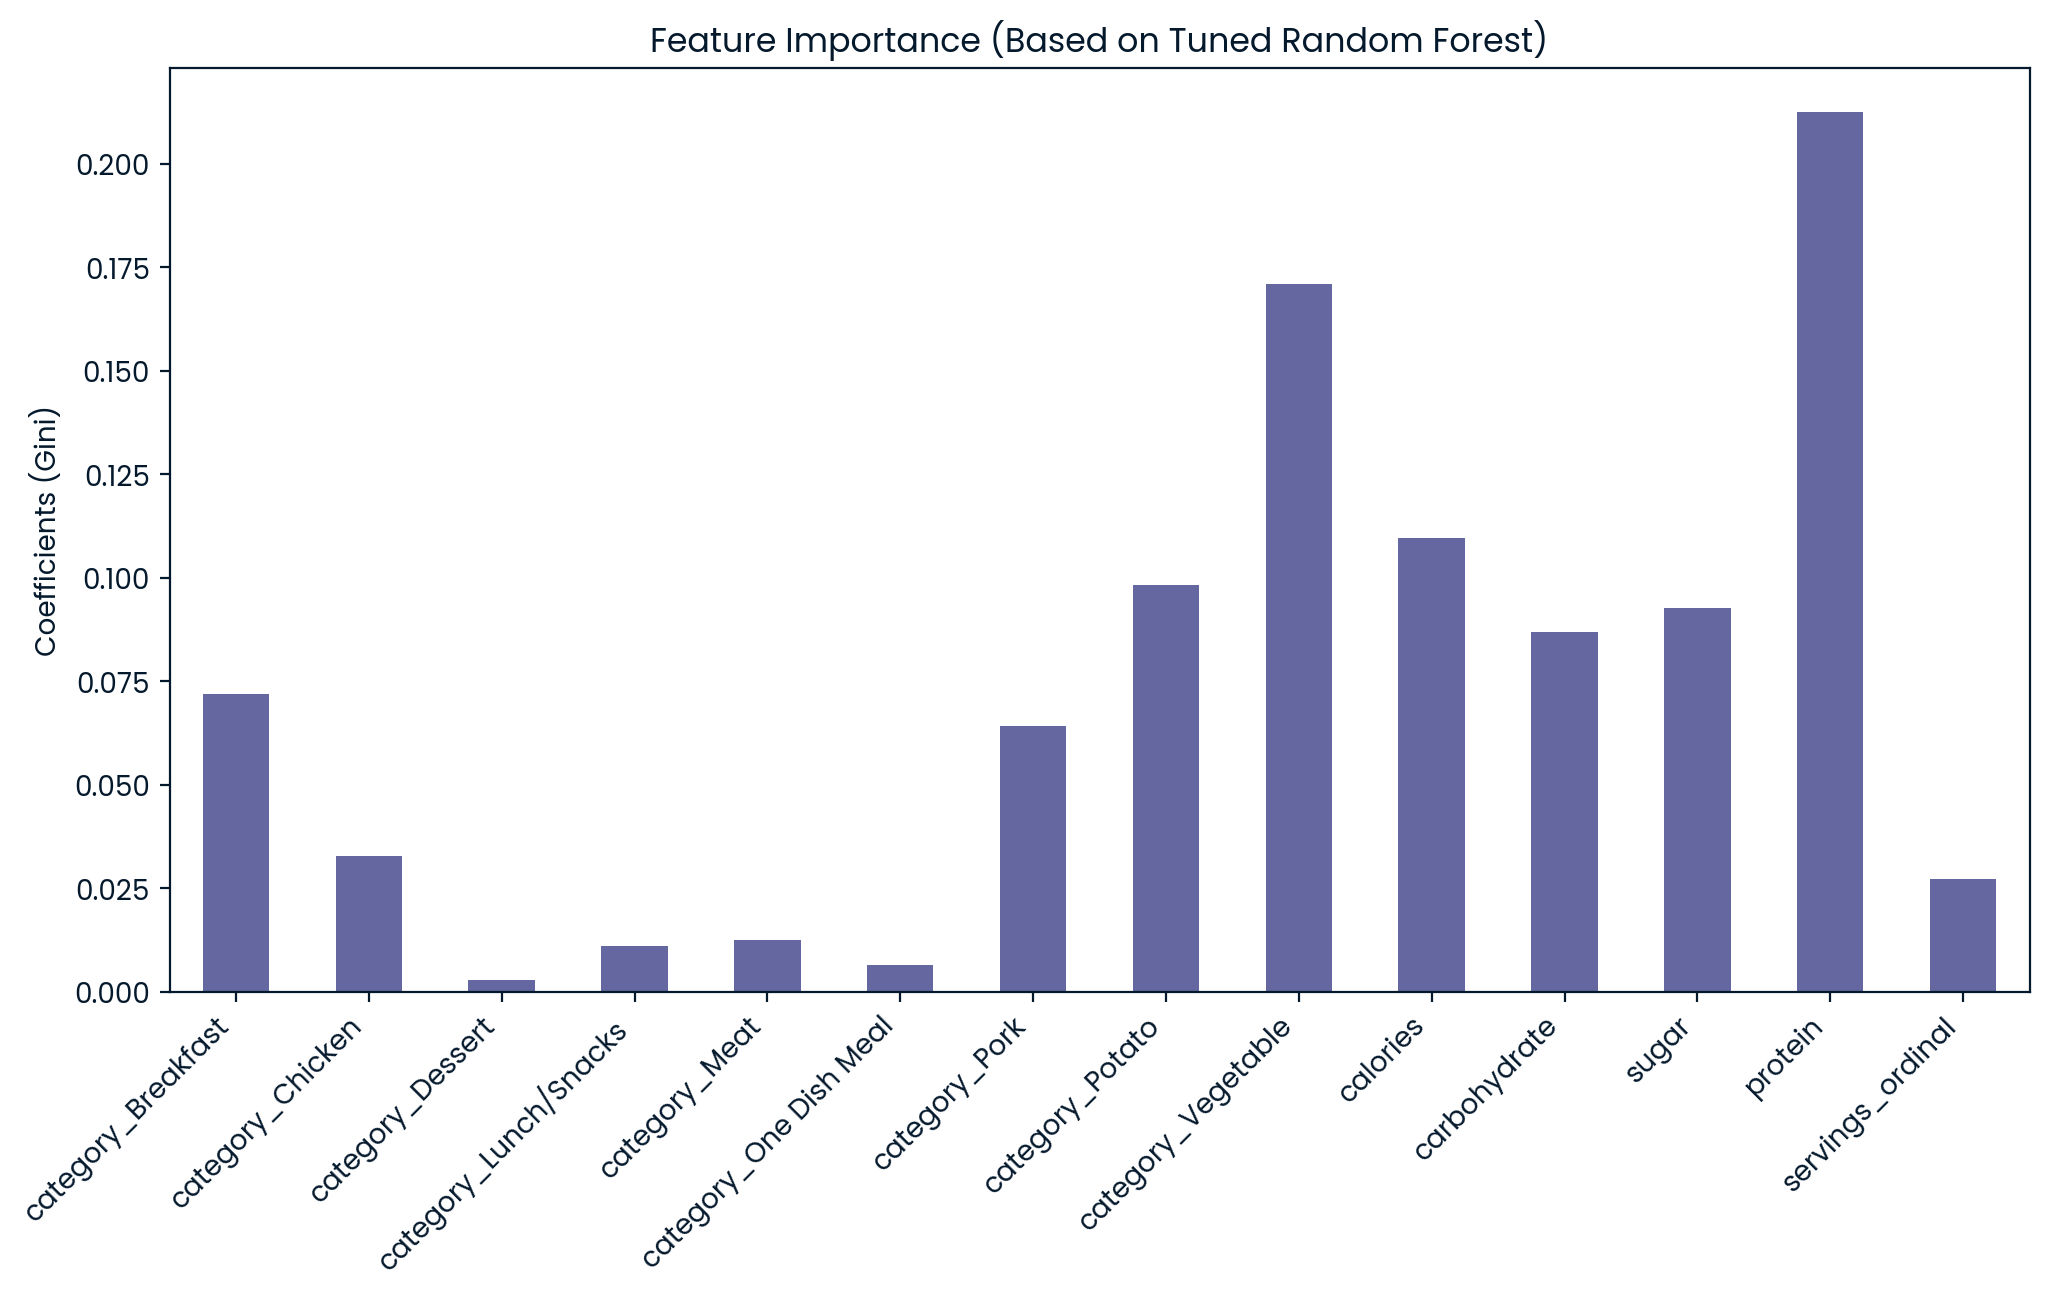

Accuracy: 0.8041958041958042
Precision: 0.8085106382978723
ROC AUC: 0.8769889840881274


In [20]:
# Start coding here...
#Before starting, its important to import all the relevant modules I will use.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
import pingouin as pg
from scipy.stats import chisquare
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

#Here, I am using pandas to turn the csv data into a dataframe so I can perform analysis 
recipes = pd.read_csv('recipe_site_traffic_2212.csv')

#Checking to see if there is any duplicated rows, there is none :)
recipes.duplicated().sum()

#Checking if any column has na values less then 5%.
for column in recipes.columns:
    if 0 < (((recipes[column].isna().sum()) / (recipes.shape[0])) * 100) < 5:
        recipes.dropna(subset=[column], inplace=True)

#Making a figure and axes so I can have all features in one plot
fig, axes = plt.subplots(2, 2, figsize=(14,10))
#Flattening axes so I can index it later 
axes = axes.flatten()

#Defining the features I want to plot. Checking if normally distributed or not.
features = ['calories','carbohydrate','sugar','protein']

for i, feature in enumerate(features):
    sns.histplot(data=recipes,x=feature, kde=True, ax=axes[i])#i can just use i to place different plots
    axes[i].set_title(f"{feature.title()} Distribution")

plt.show()

'''All these are right-skewed, so to fill missing values we will use median.

Before we need to remove outliers from our dataset
'''

for feature in features:
    Q1 = recipes[feature].quantile(0.25)
    Q3 = recipes[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    recipes = recipes[((recipes[feature] >= lower_bound) & 
    (recipes[feature] <= upper_bound)) |
    (recipes[feature].isna())]
    
#Here we are using SimpleImputer to impute median values for all missing data 
Imputer = SimpleImputer(missing_values=np.nan, strategy='median')
recipes[features] = Imputer.fit_transform(recipes[features])

#Now we need to check 
#Checking if any continous (numerical) data is correlated linearly
correlated = recipes[features].corr()
sns.heatmap(correlated, annot=True, cmap="coolwarm", fmt=".2f",  vmin=-1, vmax=1)
plt.show()

#Here I am cleaning categorical data, replacing and changing datatype.
recipes['category'] = recipes['category'].str.replace('Chicken Breast','Chicken').astype('category')
recipes['servings'] = recipes['servings'].str.replace('4 as a snack','4')
recipes['servings'] = pd.Categorical(
    recipes['servings'],
    categories=['1', '2', '4','6'],
    ordered=True
)
recipes["high_traffic"] = (
    recipes["high_traffic"].fillna(0).replace("High", 1).astype("category")
)
recipes["servings_ordinal"] = recipes["servings"].cat.codes


plt.figure(figsize=(6, 4))
sns.countplot(data=recipes, x="high_traffic")
plt.title("Distribution of High Traffic Recipes")
plt.xlabel("High Traffic")
plt.ylabel("Number of Recipes")
plt.show()

#Now, to figure out what features effect high traffic before predicting, we can use some hypothesis testing
#We know 'calories','carbohydrate','sugar','protein' are continuous data so we can use MWU tests against categorical 'high traffic' and for categorical against categorical we use chii2 contingency table


Probability_feature_importance = pd.DataFrame({
    'Feature':[],
    'P-val':[]
})

#MWU test for each feature
for feature in features:
    high_traffic = recipes[recipes['high_traffic'] == 1]
    low_traffic = recipes[recipes['high_traffic'] == 0]
    test = pg.mwu(x=high_traffic[feature], y=low_traffic[feature])
    p_val = test["p-val"].values[0]
    if p_val < 0.05:
        Probability_feature_importance.loc[len(Probability_feature_importance)] = [feature, p_val]

#chi2 independence test for categorical data
for feature in ['servings','category']:
    expected, observed, stats = pg.chi2_independence(
        data=recipes, x=feature, y="high_traffic"
    )
    if stats.iloc[0,4] < 0.05:
        Probability_feature_importance.loc[len(Probability_feature_importance)] = [feature,stats.iloc[0,4]]#append to features_to_use

#creating dummy variables, defining X,y along with splitting this into train_test split with stratified sampling
numeric_features = ["calories", "carbohydrate", "sugar", "protein", "servings_ordinal"]
dummy_vals = pd.get_dummies(
    recipes[["category"]],
    drop_first=True)
X = pd.concat([dummy_vals, recipes[numeric_features]], axis=1)
y = recipes["high_traffic"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8, stratify=y)

#Baseline model, logistic regression with scaling.

X_train_scaled = X_train.copy()#creating copies so it dont interfere with comparison model
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

log = LogisticRegression(max_iter=200, random_state=8)

log.fit(X_train_scaled, y_train)
coefs = log.coef_[0]
names = X_train_scaled.columns

#plot sho
plt.figure(figsize=(12, 6))
plt.bar(names, coefs)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Coefficients (Ridge)")
plt.title("Feature Importance (Based on Logistic model)")
plt.show()

y_pred = log.predict(X_test_scaled)
y_pred_probs = log.predict_proba(X_test_scaled)[:,1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs))


#Our comparision model will be RandomForestClassifier, which scaling is unnecessary for, and will contain cross-validation and hyperparameter tuning.

rf = RandomForestClassifier(random_state=8)
parameter_tuning = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    }
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=parameter_tuning,
    n_iter=10,  # Randomly samples 10 combinations to save time
    cv=5,
    scoring="accuracy",
    random_state=8,
    n_jobs=-1,
)

#fit the randomised search with rf estimator to training set, found the best hyperparameter (or model), predicted on test set and evaluated using performance metrics like precision, accuracy, ROC AUC. 
rf_search.fit(X_train,y_train)
optimal_rf = rf_search.best_estimator_
y_pred_rf = optimal_rf.predict(X_test)
y_pred_probs_rf = optimal_rf.predict_proba(X_test)[:, 1]
rf_features = optimal_rf.feature_importances_
feature_names = X_train.columns
rf_series = pd.Series(rf_features, index=feature_names)

plt.figure(figsize=(12, 6))
rf_series.plot(kind="bar")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Coefficients (Gini)")
plt.title("Feature Importance (Based on Tuned Random Forest)")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs_rf))



## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation